<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/Copy_of_Copy_of_Another_copy_of_02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Anlysis & Preprocessing

This notebook performs exploratory data analysis and preprocessing on the Instacart dataset.

The goal is understand the data, detcet issue, and prepare features for modeling.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
!ls /content

drive  sample_data


In [6]:
!ls /content/drive

MyDrive


In [7]:
!ls /content/drive/MyDrive

'Colab Notebooks'   DS230_Final_Project   instacart_data


In [11]:
import os
os.listdir('/content/drive/MyDrive/instacart_data/instacart_data')


['departments.csv',
 'aisles.csv',
 'order_products__prior.csv',
 'order_products__train.csv',
 'products.csv',
 'orders.csv']

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.listdir()

pd.set_option('display.max_columns' , None)


# Load Dataset Files
We load all Instacart dataset files using pandas.

In [13]:
import pandas as pd
import numpy as np
import os

DATA_PATH = '/content/drive/MyDrive/instacart_data/instacart_data'


orders = pd.read_csv(os.path.join(DATA_PATH, 'orders.csv'))
products = pd.read_csv(os.path.join(DATA_PATH, 'products.csv'))
order_products_prior = pd.read_csv(os.path.join(DATA_PATH, 'order_products__prior.csv'))
order_products_train = pd.read_csv(os.path.join(DATA_PATH, 'order_products__train.csv'))
aisles = pd.read_csv(os.path.join(DATA_PATH, 'aisles.csv'))
departments = pd.read_csv(os.path.join(DATA_PATH, 'departments.csv'))


##Data Overview
We inspect the structure and basic statistics of each dataset.


In [15]:

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)
print("Aisles shape:", aisles.shape)
print("Departments shape:", departments.shape)


Orders shape: (3421083, 7)
Products shape: (49688, 4)
Aisles shape: (134, 2)
Departments shape: (21, 2)


In [18]:
order.info()
orders.heads()

products.info()
products.head()




NameError: name 'order' is not defined

##Missing Value Analysis
We analyze missing value in the datasets.


In [19]:
orders.isnull().sum()
products.isnull().sum

<bound method DataFrame.sum of        product_id  product_name  aisle_id  department_id
0           False         False     False          False
1           False         False     False          False
2           False         False     False          False
3           False         False     False          False
4           False         False     False          False
...           ...           ...       ...            ...
49683       False         False     False          False
49684       False         False     False          False
49685       False         False     False          False
49686       False         False     False          False
49687       False         False     False          False

[49688 rows x 4 columns]>

##Distribution of Orders per User
This plot shows how many orders each user has placed.

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

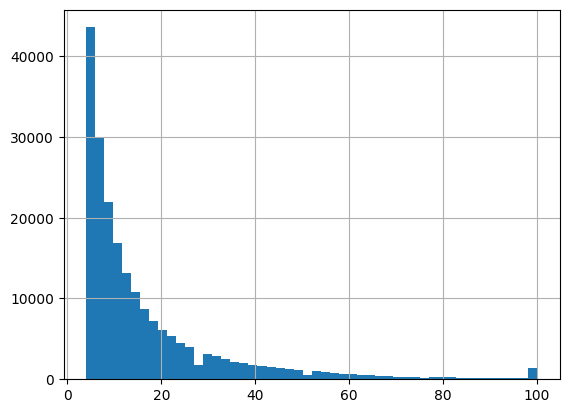

In [20]:

orders.groupby("user_id")["order_number"].max().hist(bins=50)
plt.xlable("Nuber of Orders")
plt.ylable("Number of Users")
plt.title("Orders per User")
plt.show()


##Days Since Prior Order Distribution
We visualize the distribution of days between user order.

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

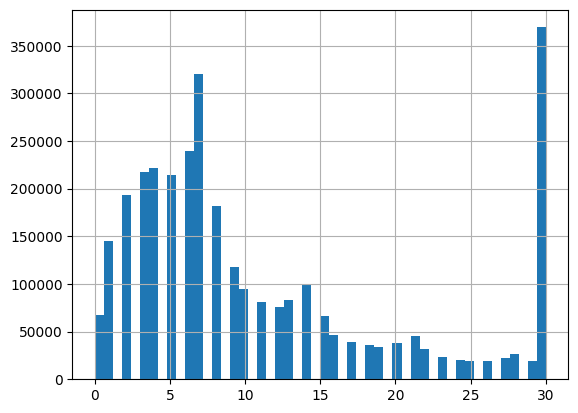

In [21]:
orders["days_since_prior_order"].hist(bins=50)
plt.xlable("Days Since Prior Order")
plt.ylable("Frequency")
plt.title("Days Between Orders")
plt.show()


## join Order and Product Data
We merge order and product dataset for futher analysis.

In [22]:
df = order_products.map(orders, on="order_id" ,how="left")
df = df.merge(product, on="product_id" ,how="left")
df = df.merge(aisles, on="aisle_id" ,how="left")
df = df.merge(departments, on="department_id" ,how="left")

NameError: name 'order_products' is not defined

## Memory Optimization
We reduce memory usage by optimizing data types.

In [23]:
df["reordered"] = df["reordered"].astype("int8")
df["order_number"] = df["order_number"].astype("int16")

NameError: name 'df' is not defined

## Target Variable Distribution
We analyze the distribution of the reordered target varible.


In [24]:
df["reordered"].value_counts(normalize=True).plot(kind="bar")
plt.title("Reorder Distribution")
plt.show()


NameError: name 'df' is not defined

##Save Cleaned Dataset
We save the processed dataset for feature engineering and modeling.

In [25]:
df.to_csv("clean_instacart_data.csv", index=False)

NameError: name 'df' is not defined